# Coordenadas de las estaciones

* NE2 (Apodaca)	25.777222, -100.188056
* NE3 (Pesquería) 25.790556, -100.078333

# Sacar Índice de Vegetación de Diferencia Normalizada (NDVI) para 500 metros alrededor de las estaciones

In [1]:
from math import asin, cos, radians, sin, sqrt


def distancia_haversine(latitud_1, longitud_1, latitud_2, longitud_2):
    """Calcula la distancia entre dos coordenadas en kilometros."""
    radio_tierra_km = 6371.0

    latitud_1, longitud_1, latitud_2, longitud_2 = map(
        radians, (latitud_1, longitud_1, latitud_2, longitud_2)
    )
    diferencia_latitud = latitud_2 - latitud_1
    diferencia_longitud = longitud_2 - longitud_1

    a = (
        sin(diferencia_latitud / 2) ** 2
        + cos(latitud_1) * cos(latitud_2) * sin(diferencia_longitud / 2) ** 2
    )
    return 2 * radio_tierra_km * asin(sqrt(a))


# NE2 (Apodaca)
latitud_ne2, longitud_ne2 = 25.777222, -100.188056

# NE3 (Pesqueria)
latitud_ne3, longitud_ne3 = 25.790556, -100.078333

distancia_km = distancia_haversine(
    latitud_ne2,
    longitud_ne2,
    latitud_ne3,
    longitud_ne3,
)

print(f"Distancia entre NE2 y NE3: {distancia_km:.2f} km")
print(f"Distancia entre NE2 y NE3: {distancia_km * 1000:.0f} m")

Distancia entre NE2 y NE3: 11.09 km
Distancia entre NE2 y NE3: 11086 m


In [2]:
# Instalar una sola vez en el entorno del notebook si hace falta:
# %pip install pystac-client planetary-computer rasterio shapely pyproj pandas numpy

import numpy as np
import pandas as pd
import planetary_computer
import rasterio
from pystac_client import Client
from rasterio.mask import mask
from shapely.geometry import Point, mapping
from shapely.ops import transform
from pyproj import Transformer


ESTACIONES = {
    "NE2": {"latitud": 25.777222, "longitud": -100.188056},
    "NE3": {"latitud": 25.790556, "longitud": -100.078333},
}
RADIO_BUFFER_METROS = 500
FECHA_INICIO = "2020-01-01"
FECHA_FIN = "2026-01-01"
MAX_NUBOSIDAD = 80


def ndvi_mensual_estacion(item, estacion):
    """Calcula la mediana del NDVI dentro del buffer para una imagen."""
    longitud = estacion["longitud"]
    latitud = estacion["latitud"]
    punto_wgs84 = Point(longitud, latitud)

    with rasterio.open(item.assets["B04"].href) as banda_roja:
        transformer = Transformer.from_crs(
            "EPSG:4326", banda_roja.crs, always_xy=True
        )
        punto_proyectado = transform(transformer.transform, punto_wgs84)
        area = punto_proyectado.buffer(RADIO_BUFFER_METROS)

        roja, _ = mask(banda_roja, [mapping(area)], crop=True, filled=False)

    with rasterio.open(item.assets["B08"].href) as banda_infrarroja:
        infrarroja, _ = mask(banda_infrarroja, [mapping(area)], crop=True, filled=False)

    roja = np.ma.asarray(roja[0], dtype="float32")
    infrarroja = np.ma.asarray(infrarroja[0], dtype="float32")
    mascara = np.ma.getmaskarray(roja) | np.ma.getmaskarray(infrarroja)
    roja = np.asarray(roja.filled(np.nan))
    infrarroja = np.asarray(infrarroja.filled(np.nan))
    denominador = infrarroja + roja

    ndvi = np.divide(
        infrarroja - roja,
        denominador,
        out=np.full_like(denominador, np.nan, dtype="float32"),
        where=(~mascara) & (denominador != 0),
    )
    valores_validos = ndvi[np.isfinite(ndvi)]

    if valores_validos.size == 0:
        return np.nan, 0

    return float(np.median(valores_validos)), int(valores_validos.size)


catalogo = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1"
)

resultados = []
for nombre_estacion, estacion in ESTACIONES.items():
    punto = Point(estacion["longitud"], estacion["latitud"])
    punto_cercano = punto.buffer(0.01)

    busqueda = catalogo.search(
        collections=["sentinel-2-l2a"],
        intersects=mapping(punto_cercano),
        datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
        query={"eo:cloud_cover": {"lt": MAX_NUBOSIDAD}},
    )

    items_por_mes = {}
    for item in busqueda.item_collection():
        mes = item.datetime.strftime("%Y-%m")
        items_por_mes.setdefault(mes, []).append(item)

    for mes in pd.date_range(FECHA_INICIO, FECHA_FIN, inclusive="left", freq="MS"):
        clave_mes = mes.strftime("%Y-%m")
        items = sorted(
            items_por_mes.get(clave_mes, []),
            key=lambda item: item.properties.get("eo:cloud_cover", 100),
        )

        ndvi_imagenes = []
        pixeles_validos = 0
        for item in items:
            item = planetary_computer.sign(item)
            ndvi_imagen, cantidad_pixeles = ndvi_mensual_estacion(item, estacion)
            if np.isfinite(ndvi_imagen):
                ndvi_imagenes.append(ndvi_imagen)
                pixeles_validos += cantidad_pixeles

        resultados.append(
            {
                "estacion": nombre_estacion,
                "mes": mes,
                "ndvi_mediana": (
                    float(np.median(ndvi_imagenes))
                    if ndvi_imagenes
                    else np.nan
                ),
                "imagenes_utilizadas": len(ndvi_imagenes),
                "pixeles_validos": pixeles_validos,
            }
        )

ndvi_mensual = pd.DataFrame(resultados)
ndvi_mensual["mes"] = pd.to_datetime(ndvi_mensual["mes"])
ndvi_mensual = ndvi_mensual.sort_values(["estacion", "mes"]).reset_index(drop=True)

ndvi_mensual.to_csv("ndvi_mensual_estaciones_2020_2025.csv", index=False)
ndvi_mensual.head(12)

,estacion,mes,ndvi_mediana,imagenes_utilizadas,pixeles_validos
0,NE2,2020-01-01,0.080188,2,15684
1,NE2,2020-02-01,0.064151,5,39210
2,NE2,2020-03-01,0.021691,4,31368
3,NE2,2020-04-01,0.043321,4,31368
4,NE2,2020-05-01,0.041306,6,47052
5,NE2,2020-06-01,0.079118,6,47052
6,NE2,2020-07-01,0.091305,5,39210
7,NE2,2020-08-01,0.089047,6,47052
8,NE2,2020-09-01,0.102299,4,31368
9,NE2,2020-10-01,0.108543,7,54894


In [3]:
ndvi_mensual.tail()

,estacion,mes,ndvi_mediana,imagenes_utilizadas,pixeles_validos
139,NE3,2025-08-01,0.200271,8,62760
140,NE3,2025-09-01,0.175850,5,39225
141,NE3,2025-10-01,0.373707,8,62760
142,NE3,2025-11-01,0.314826,7,54915
143,NE3,2025-12-01,0.236737,6,47070


In [4]:
ndvi_NE2 = ndvi_mensual[ndvi_mensual["estacion"] == "NE2"].copy()
ndvi_NE3 = ndvi_mensual[ndvi_mensual["estacion"] == "NE3"].copy()

In [5]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'NDVI Mediana Mensual - Estación NE2'}, xlabel='Mes', ylabel='NDVI Mediana'>

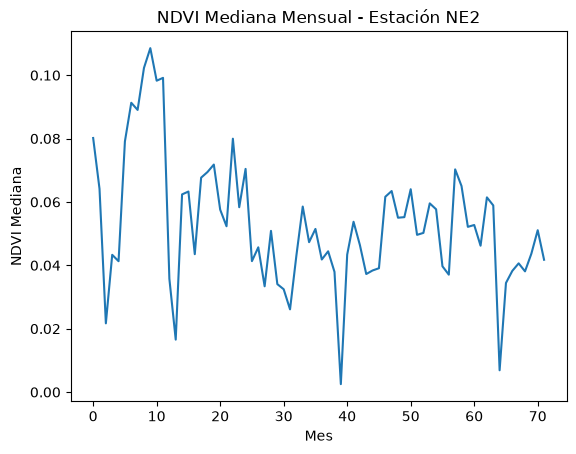

In [6]:
ndvi_NE2['ndvi_mediana'].plot(kind='line', title='NDVI Mediana Mensual - Estación NE2', xlabel='Mes', ylabel='NDVI Mediana')

<Axes: title={'center': 'NDVI Mediana Mensual - Estación NE3'}, xlabel='Mes', ylabel='NDVI Mediana'>

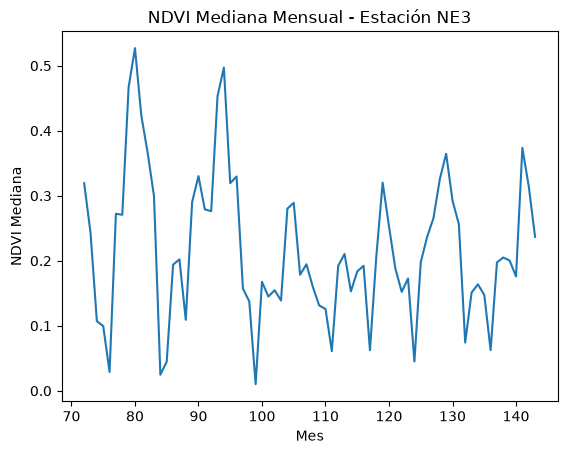

In [7]:
ndvi_NE3['ndvi_mediana'].plot(kind='line', title='NDVI Mediana Mensual - Estación NE3', xlabel='Mes', ylabel='NDVI Mediana')

In [8]:
NE3 = pd.read_csv('../data_estaciones/BD_NE3.csv') # Pesquería
NE2 = pd.read_csv('../data_estaciones/BD_NE2.csv') # Apodaca

In [10]:
NE2['date'] = pd.to_datetime(NE2['date'])
NE3['date'] = pd.to_datetime(NE3['date'])

<Axes: title={'center': 'PM10 - Estación NE2'}, xlabel='Fecha', ylabel='PM10 (µg/m³)'>

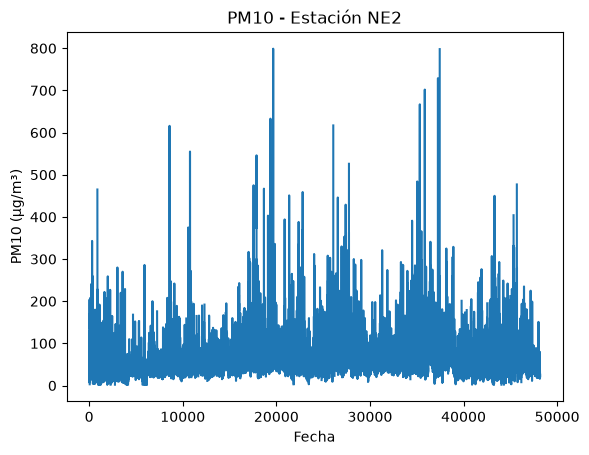

In [11]:
NE2['PM10'].plot(kind='line', title='PM10 - Estación NE2', xlabel='Fecha', ylabel='PM10 (µg/m³)')

<Axes: title={'center': 'PM10 - Estación NE3'}, xlabel='Fecha', ylabel='PM10 (µg/m³)'>

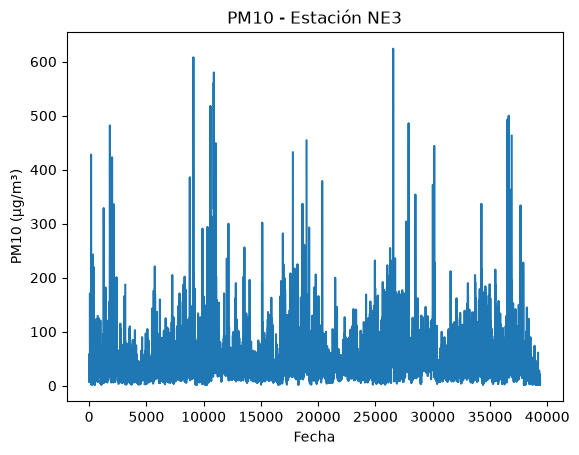

In [12]:
NE3['PM10'].plot(kind='line', title='PM10 - Estación NE3', xlabel='Fecha', ylabel='PM10 (µg/m³)')

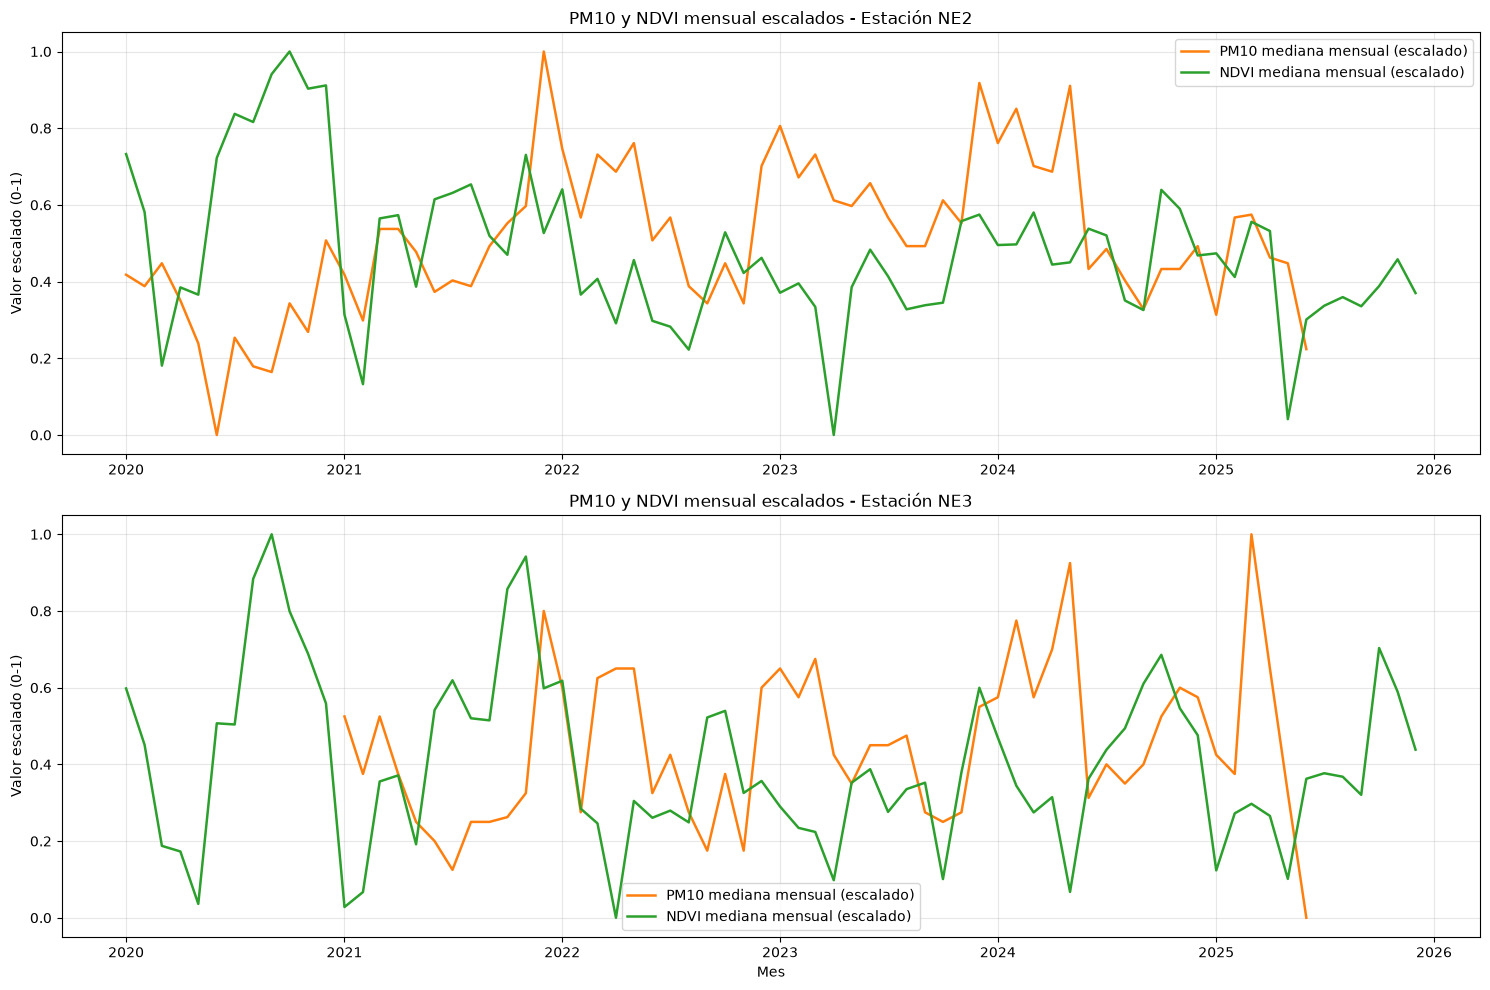

(         mes  pm10_mediana  ndvi_mediana  pm10_escalado  ndvi_escalado
 0 2020-01-01          52.0      0.080188       0.417910       0.732585
 1 2020-02-01          50.0      0.064151       0.388060       0.581345
 2 2020-03-01          54.0      0.021691       0.447761       0.180916
 3 2020-04-01          47.5      0.043321       0.350746       0.384899
 4 2020-05-01          40.0      0.041306       0.238806       0.365902,
          mes  pm10_mediana  ndvi_mediana  pm10_escalado  ndvi_escalado
 0 2020-01-01           NaN      0.319251            NaN       0.597981
 1 2020-02-01           NaN      0.243264            NaN       0.450952
 2 2020-03-01           NaN      0.107130            NaN       0.187539
 3 2020-04-01           NaN      0.099539            NaN       0.172851
 4 2020-05-01           NaN      0.028916            NaN       0.036199)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def escalar_min_max(serie):
    """Escala una serie al intervalo [0, 1], ignorando valores faltantes."""
    minimo = serie.min()
    maximo = serie.max()
    if pd.isna(minimo) or minimo == maximo:
        return serie * 0
    return (serie - minimo) / (maximo - minimo)


def preparar_datos_estacion(datos_pm10, nombre_estacion):
    """Agrega PM10 por mes y lo combina con el NDVI mensual."""
    pm10_mensual = (
        datos_pm10.assign(mes=datos_pm10["date"].dt.to_period("M").dt.to_timestamp())
        .groupby("mes", as_index=False)["PM10"]
        .median()
        .rename(columns={"PM10": "pm10_mediana"})
    )

    ndvi_estacion = ndvi_mensual.loc[
        ndvi_mensual["estacion"] == nombre_estacion,
        ["mes", "ndvi_mediana"],
    ]
    # Solo se comparan meses con PM10 y NDVI disponibles en la estación.
    datos = pm10_mensual.merge(ndvi_estacion, on="mes", how="inner")
    datos = datos.sort_values("mes")
    datos["pm10_escalado"] = escalar_min_max(datos["pm10_mediana"])
    datos["ndvi_escalado"] = escalar_min_max(datos["ndvi_mediana"])
    return datos


NE2["date"] = pd.to_datetime(NE2["date"])
NE3["date"] = pd.to_datetime(NE3["date"])

serie_NE2 = preparar_datos_estacion(NE2, "NE2")
serie_NE3 = preparar_datos_estacion(NE3, "NE3")

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes,
    [serie_NE2, serie_NE3],
    ["NE2", "NE3"],
):
    eje.plot(
        datos["mes"],
        datos["pm10_escalado"],
        label="PM10 mediana mensual (escalado)",
        color="tab:orange",
        linewidth=1.8,
    )
    eje.plot(
        datos["mes"],
        datos["ndvi_escalado"],
        label="NDVI mediana mensual (escalado)",
        color="tab:green",
        linewidth=1.8,
    )
    eje.set_title(f"PM10 y NDVI mensual escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

# NE3 empieza en 2021 porque no tiene observaciones de 2020.
ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

serie_NE2.head(), serie_NE3.head()